/tmp/ipykernel_4015546/4156565336.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='9', loc='best')


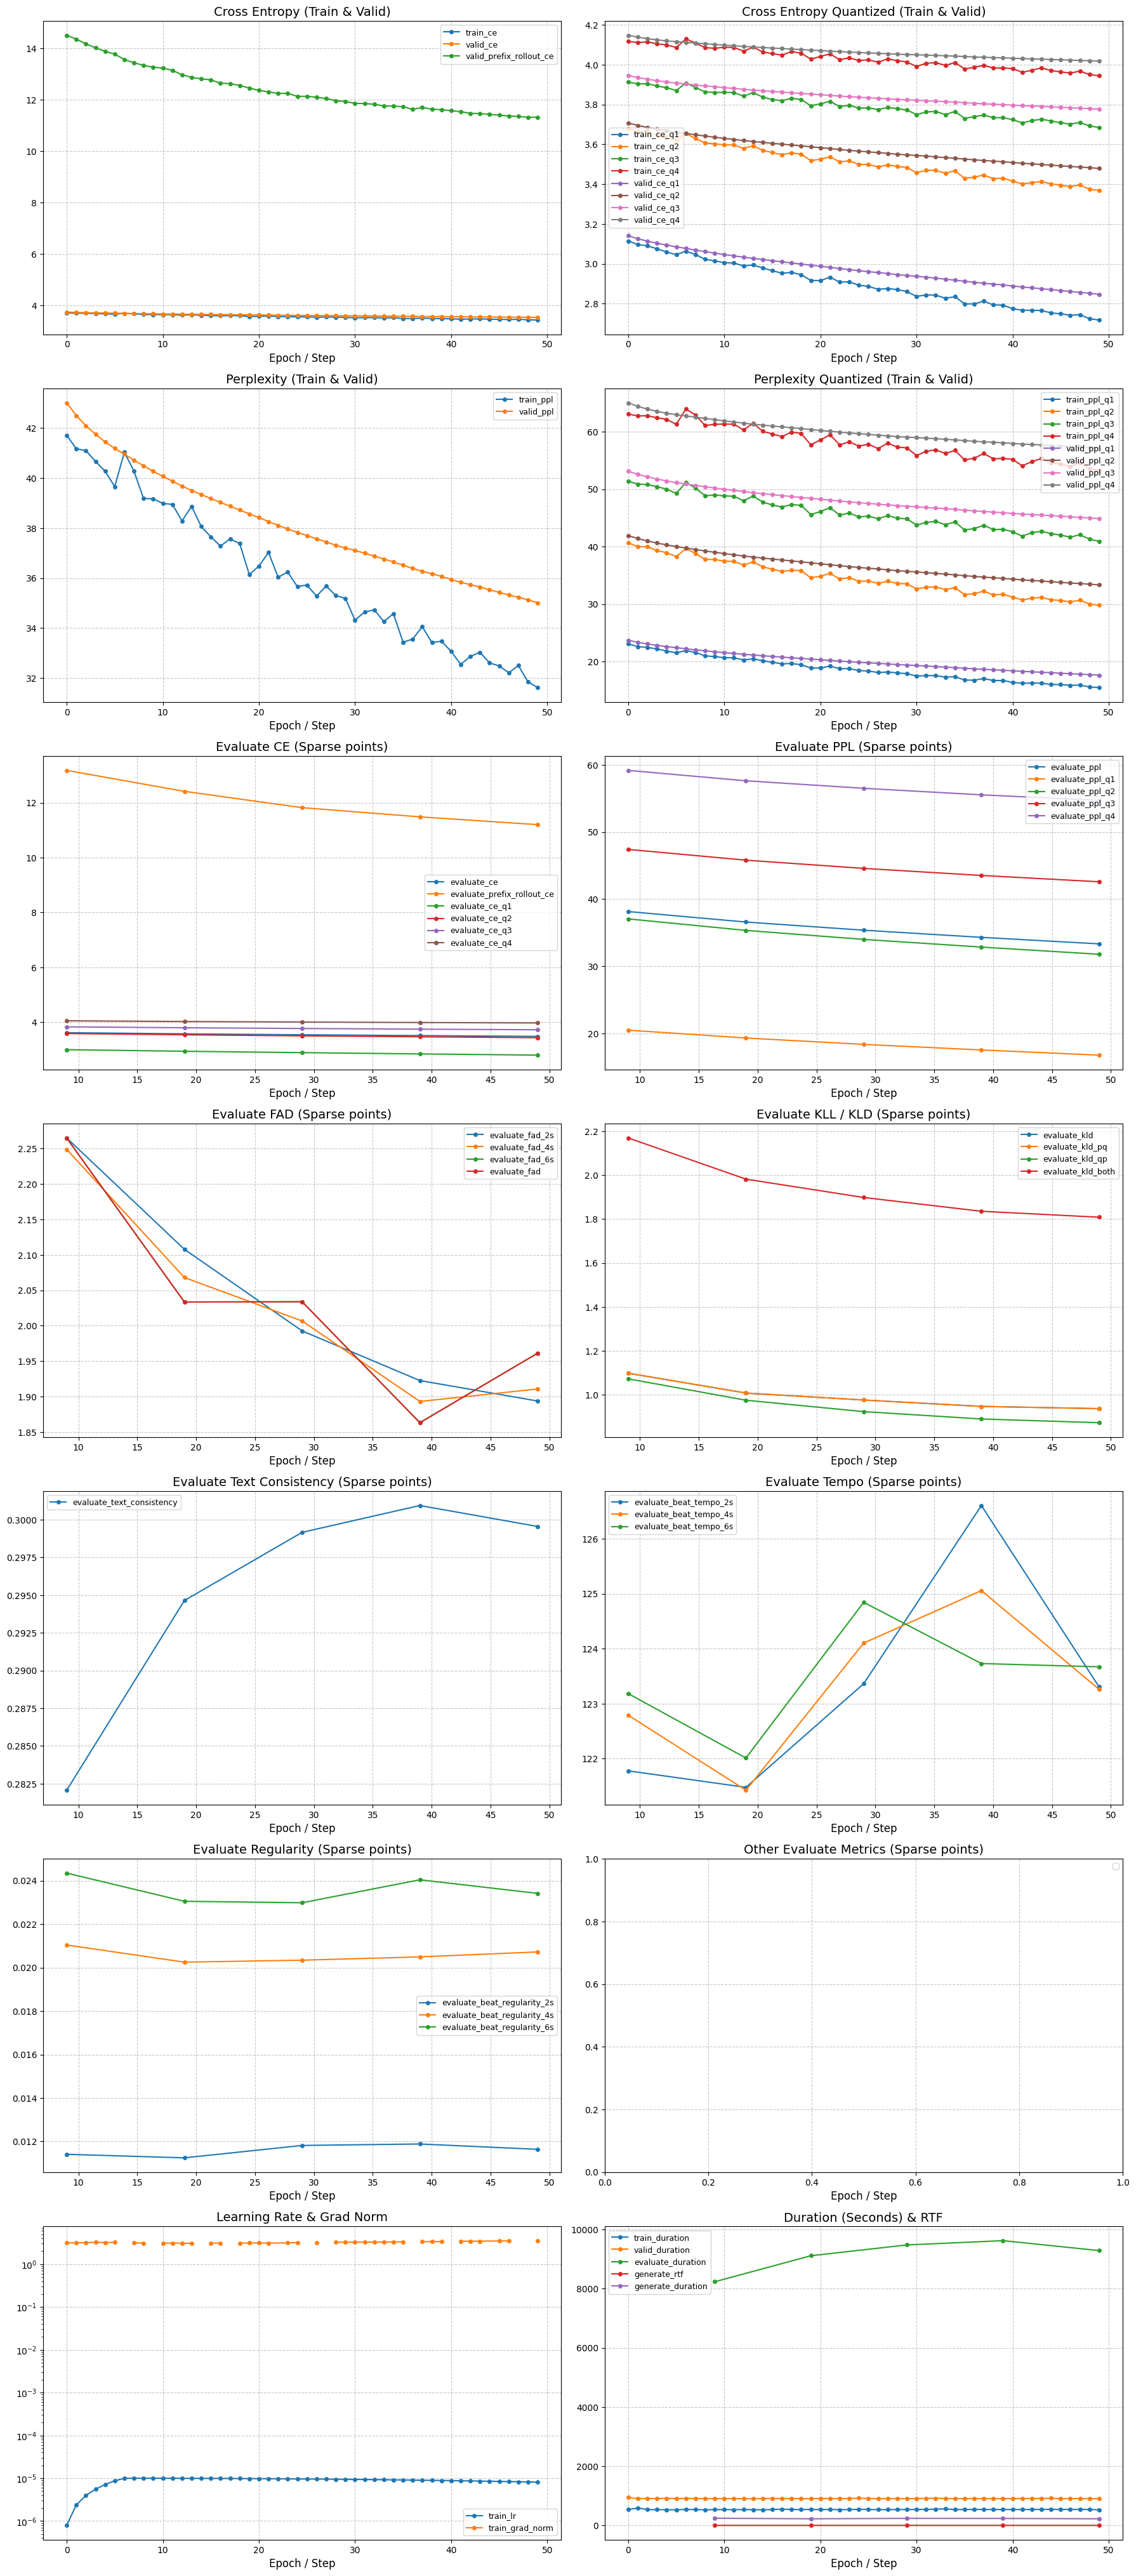

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
with open('/storage/ssd1/richtsai1103/MusicBench/dora_outputs/20260328_041339/xps/d0613dbf/history.json', 'r') as f:
    data = json.load(f)

# Flatten the data into a list of dictionaries to create a DataFrame
records = []
for i, step in enumerate(data):
    row = {'step': i}
    for phase, metrics in step.items():
        for k, v in metrics.items():
            row[f"{phase}_{k}"] = v
    records.append(row)

df = pd.DataFrame(records)

# Group metrics to plot them in logical subplots
ce_cols = [c for c in df.columns if 'ce' in c and 'ce_q' not in c and 'evaluate' not in c]
ce_q_cols = [c for c in df.columns if 'ce_q' in c and 'evaluate' not in c]
ppl_cols = [c for c in df.columns if 'ppl' in c and 'ppl_q' not in c and 'evaluate' not in c]
ppl_q_cols = [c for c in df.columns if 'ppl_q' in c and 'evaluate' not in c]

# Group evaluate specific stuff
eval_ce = [c for c in df.columns if 'evaluate' in c and 'ce' in c]
eval_ppl = [c for c in df.columns if 'evaluate' in c and 'ppl' in c]

# Each major evaluate metric gets its own group
eval_fad         = [c for c in df.columns if 'evaluate' in c and 'fad' in c.lower()]
eval_kll         = [c for c in df.columns if 'evaluate' in c and ('kll' in c.lower() or 'kld' in c.lower())]
eval_consistency = [c for c in df.columns if 'evaluate' in c and 'consistency' in c.lower()]
eval_tempo       = [c for c in df.columns if 'evaluate' in c and 'tempo' in c.lower()]
eval_regularity  = [c for c in df.columns if 'evaluate' in c and 'regularity' in c.lower()]
eval_other       = [c for c in df.columns if 'evaluate' in c
                    and 'ce' not in c and 'ppl' not in c and 'duration' not in c
                    and 'fad' not in c.lower() and 'kll' not in c.lower() and 'kld' not in c.lower()
                    and 'consistency' not in c.lower() and 'tempo' not in c.lower()
                    and 'regularity' not in c.lower()]

dur_cols = [c for c in df.columns if 'duration' in c or 'rtf' in c]

# Create subplots - Now 8x2 to accommodate all graphs
fig, axes = plt.subplots(8, 2, figsize=(18, 46))
axes = axes.flatten()

def plot_cols(ax, cols, title, logy=False):
    for c in cols:
        if c in df.columns:
            valid_data = df[['step', c]].dropna()
            ax.plot(valid_data['step'], valid_data[c], label=c, marker='o', markersize=4)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Epoch / Step', fontsize=12)
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize='9', loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)

# Core train/valid metrics
plot_cols(axes[0], ce_cols,    'Cross Entropy (Train & Valid)')
plot_cols(axes[1], ce_q_cols,  'Cross Entropy Quantized (Train & Valid)')
plot_cols(axes[2], ppl_cols,   'Perplexity (Train & Valid)')
plot_cols(axes[3], ppl_q_cols, 'Perplexity Quantized (Train & Valid)')

# Evaluate metrics - each in its own subplot
plot_cols(axes[4],  eval_ce,          'Evaluate CE (Sparse points)')
plot_cols(axes[5],  eval_ppl,         'Evaluate PPL (Sparse points)')
plot_cols(axes[6],  eval_fad,         'Evaluate FAD (Sparse points)')
plot_cols(axes[7],  eval_kll,         'Evaluate KLL / KLD (Sparse points)')
plot_cols(axes[8],  eval_consistency, 'Evaluate Text Consistency (Sparse points)')
plot_cols(axes[9],  eval_tempo,       'Evaluate Tempo (Sparse points)')
plot_cols(axes[10], eval_regularity,  'Evaluate Regularity (Sparse points)')
plot_cols(axes[11], eval_other,       'Other Evaluate Metrics (Sparse points)')

# Training diagnostics
plot_cols(axes[12], ['train_lr', 'train_grad_norm'], 'Learning Rate & Grad Norm', logy=True)
plot_cols(axes[13], dur_cols,                        'Duration (Seconds) & RTF')

# All 16 slots used - hide the last two empty ones
axes[14].set_visible(False)
axes[15].set_visible(False)

plt.tight_layout()
plt.savefig('history_metrics.png', dpi=150, bbox_inches='tight')

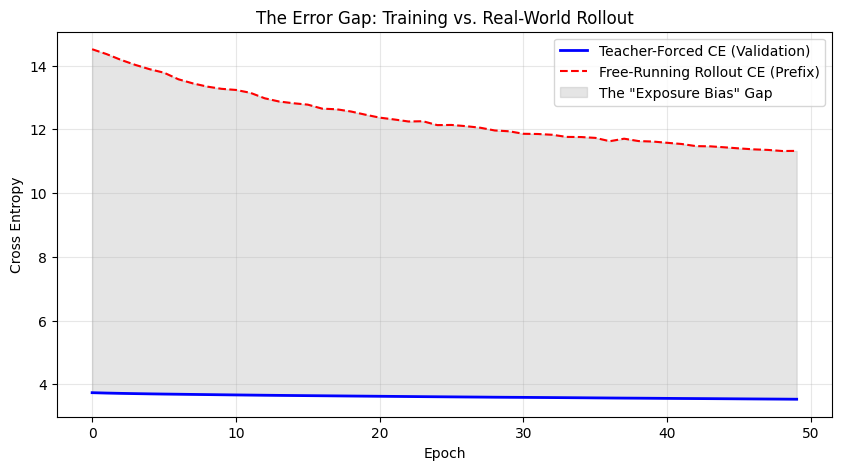

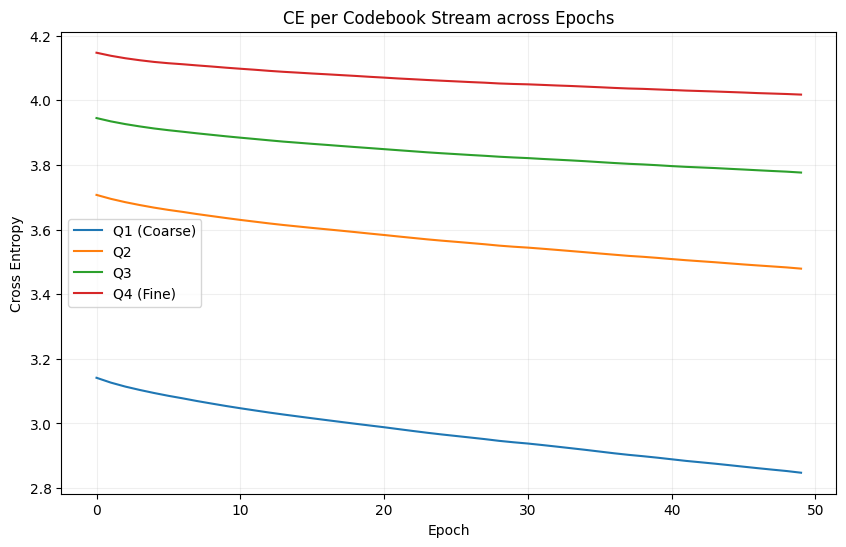

--- Per-Stream Error Reduction (Epoch 0 to End) ---
Q1 (Coarse): 0.2939 CE improvement
Q2: 0.2282 CE improvement
Q3: 0.1687 CE improvement
Q4 (Fine): 0.1296 CE improvement


In [2]:
import json
import matplotlib.pyplot as plt

with open('/storage/ssd1/richtsai1103/MusicBench/dora_outputs/20260328_041339/xps/d0613dbf/history.json', 'r') as f:
    data = json.load(f)

epochs = range(len(data))
valid_ce = [step['valid']['ce'] for step in data]
rollout_ce = [step['valid']['prefix_rollout_ce'] for step in data]

plt.figure(figsize=(10, 5))
plt.plot(epochs, valid_ce, label='Teacher-Forced CE (Validation)', color='blue', lw=2)
plt.plot(epochs, rollout_ce, label='Free-Running Rollout CE (Prefix)', color='red', linestyle='--')
plt.fill_between(epochs, valid_ce, rollout_ce, color='gray', alpha=0.2, label='The "Exposure Bias" Gap')

plt.title('The Error Gap: Training vs. Real-World Rollout')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Extracting per-stream validation metrics
q_metrics = {
    'Q1 (Coarse)': [s['valid']['ce_q1'] for s in data],
    'Q2': [s['valid']['ce_q2'] for s in data],
    'Q3': [s['valid']['ce_q3'] for s in data],
    'Q4 (Fine)': [s['valid']['ce_q4'] for s in data]
}

plt.figure(figsize=(10, 6))
for label, values in q_metrics.items():
    plt.plot(epochs, values, label=label)

plt.title('CE per Codebook Stream across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Calculate Per-Stream Overall Gap (Start vs. End of Training)
print("--- Per-Stream Error Reduction (Epoch 0 to End) ---")
for label, values in q_metrics.items():
    total_reduction = values[0] - values[-1]
    print(f"{label}: {total_reduction:.4f} CE improvement")

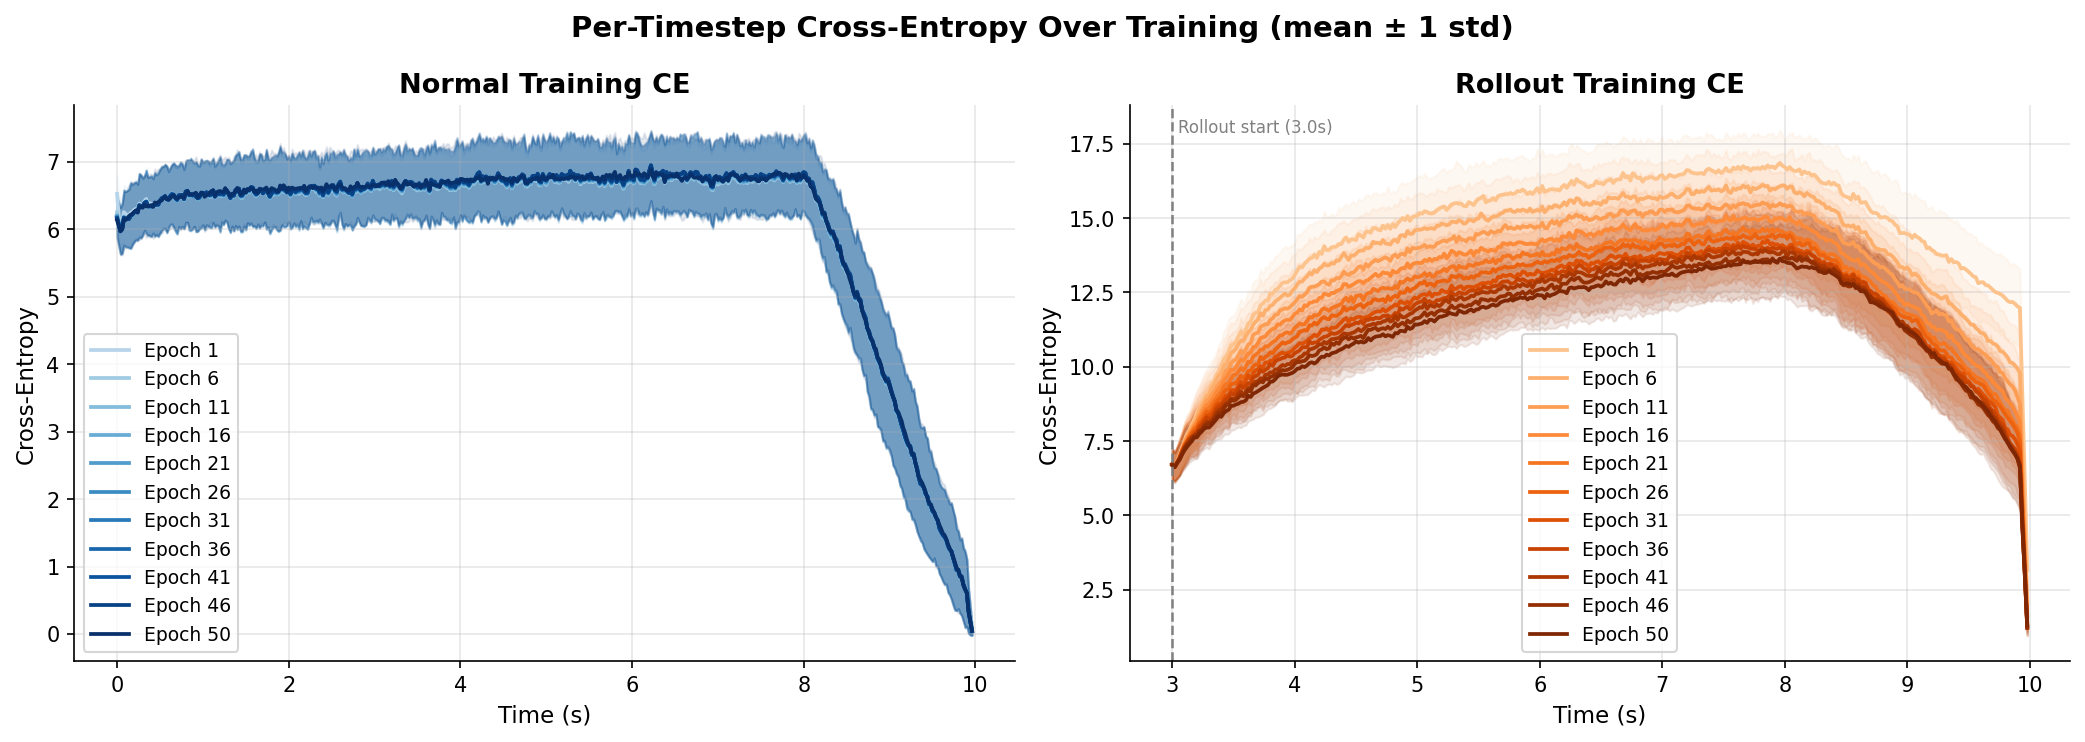

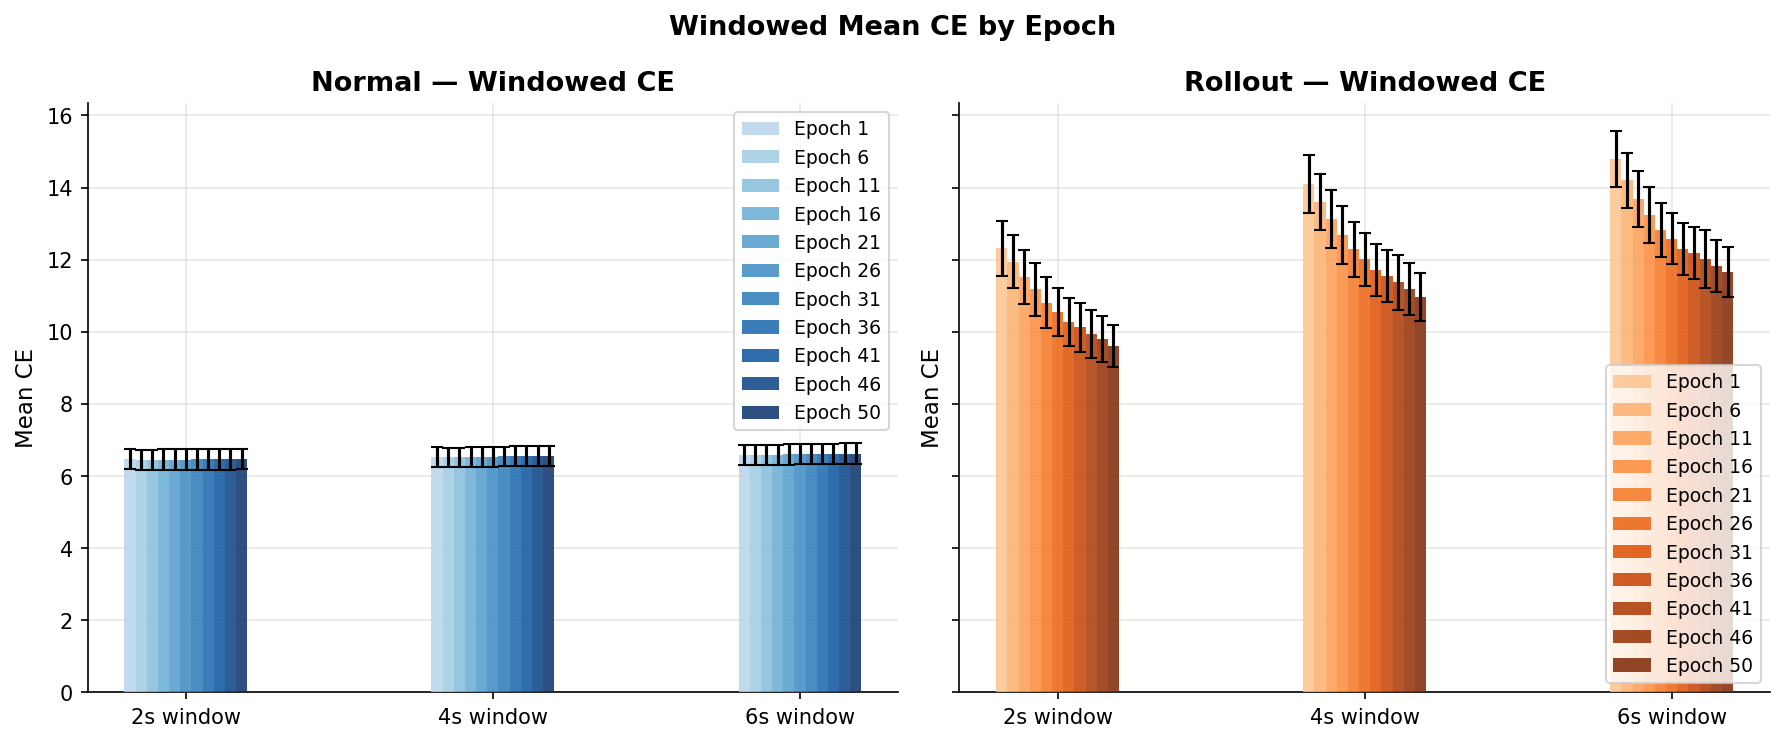

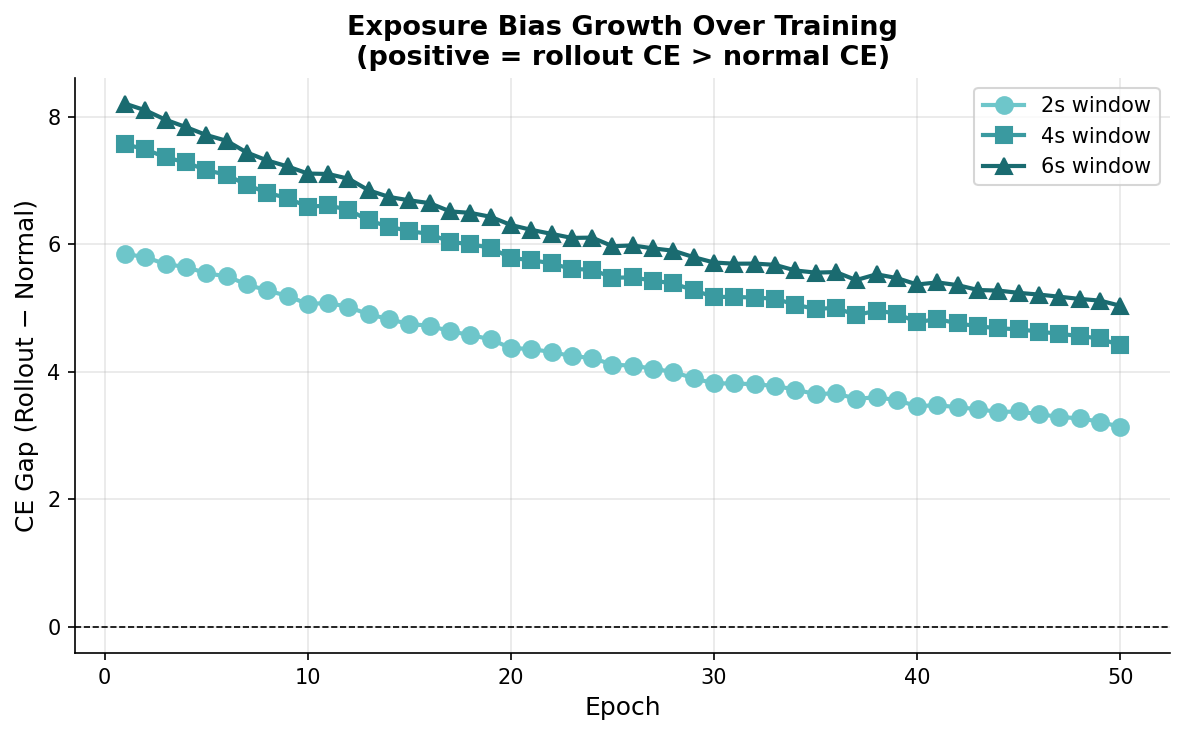

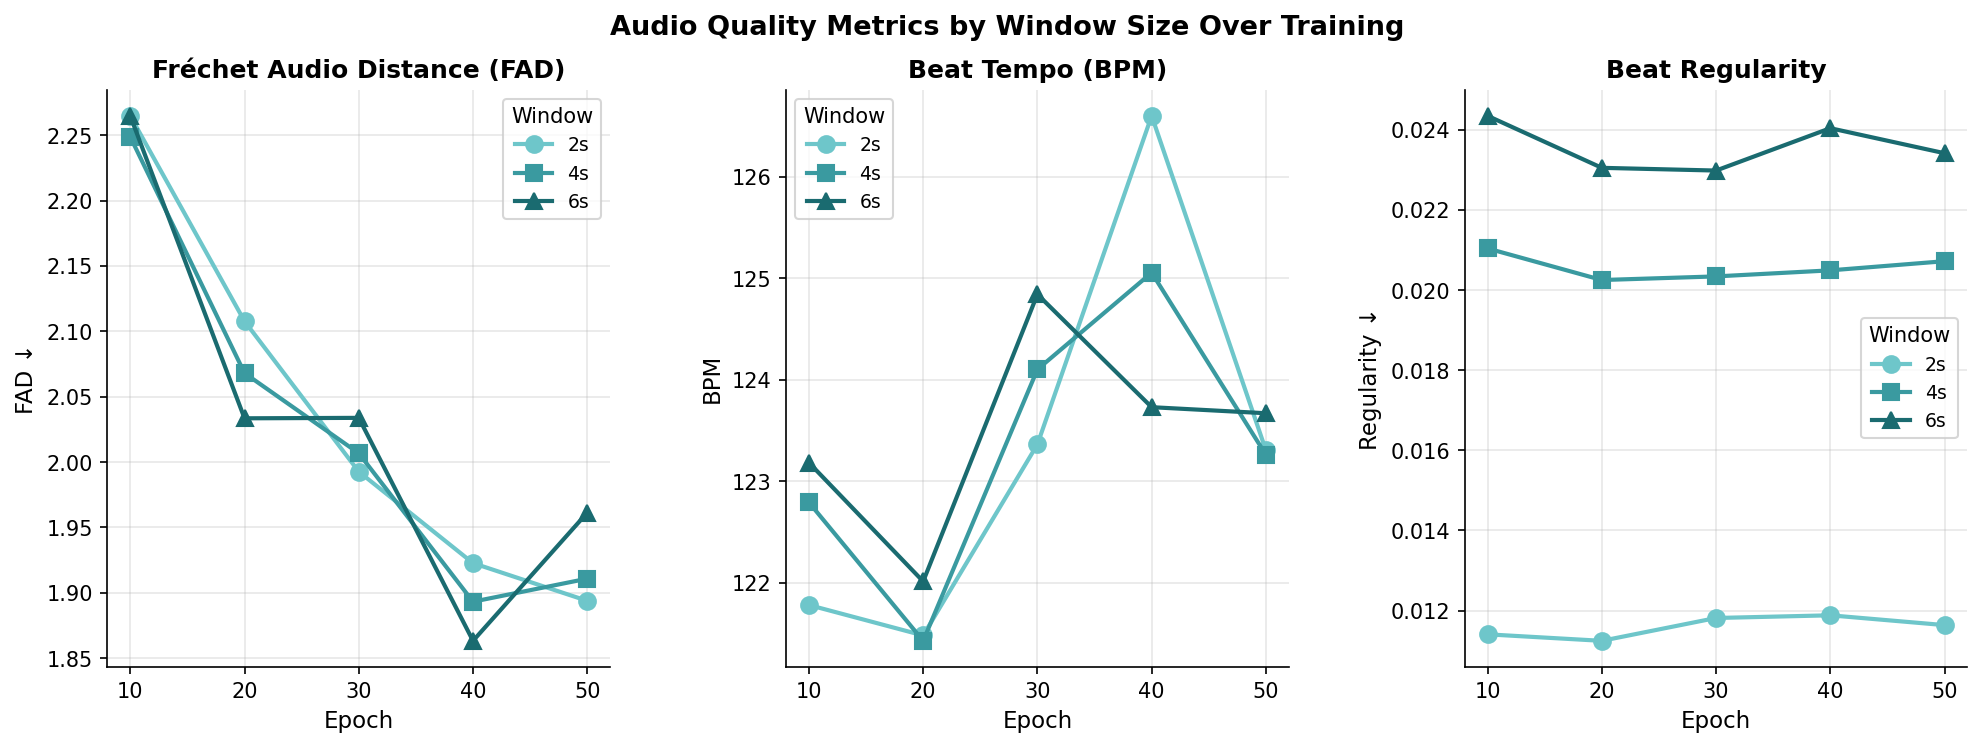

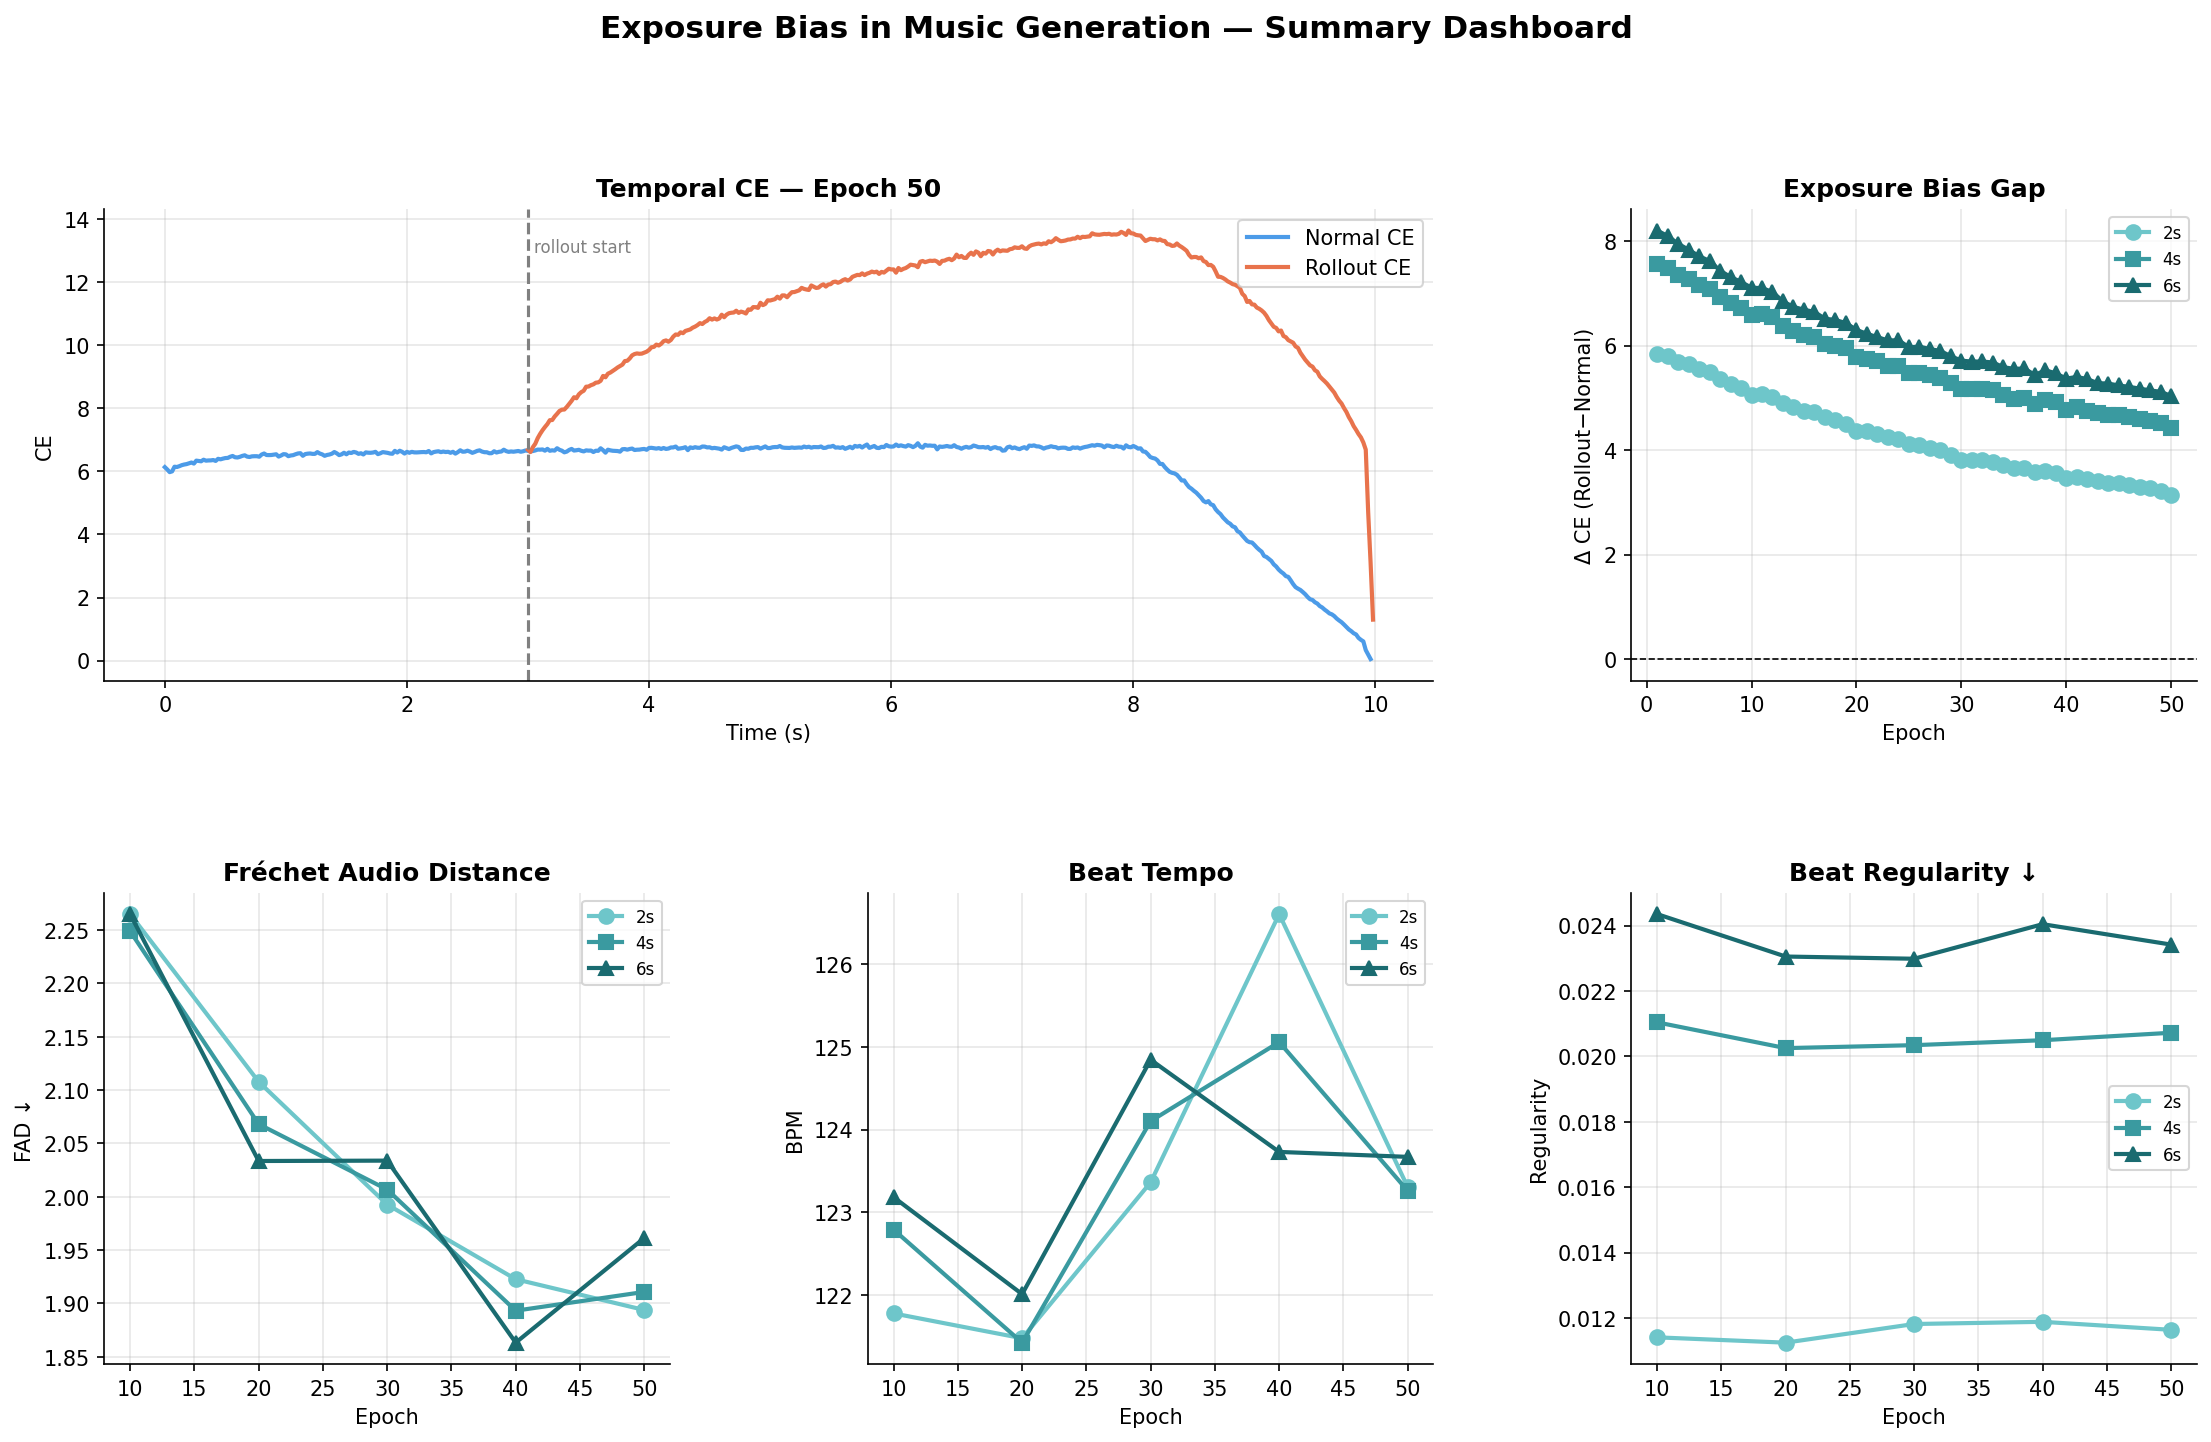

In [7]:
"""
Exposure Bias Analysis — Music Generation
Plots temporal CE curves, windowed CE comparisons, and audio quality metrics.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from pathlib import Path
import matplotlib.cm as cm


# ── file paths ───────────────────────────────────────────────────────────────
BASE = Path("/storage/ssd1/richtsai1103/MusicBench/dora_outputs/20260328_041339/temporal_logs")
NORMAL_FILE  = BASE / "normal_ce_temporal.jsonl"
ROLLOUT_FILE = BASE / "rollout_ce_temporal.jsonl"
AUDIO_FILE   = BASE / "windowed_audio_metrics.jsonl"

def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# ── load data ─────────────────────────────────────────────────────────────────
normal_records  = load_jsonl(NORMAL_FILE)
rollout_records = load_jsonl(ROLLOUT_FILE)
audio_records   = load_jsonl(AUDIO_FILE)

# ── helpers ───────────────────────────────────────────────────────────────────
def aggregate_per_timestep(records):
    epoch_data = defaultdict(lambda: defaultdict(list))
    for rec in records:
        epoch = rec["epoch"]
        for ts in rec["per_timestep"]:
            epoch_data[epoch][ts["frame"]].append(ts["ce"])
    return epoch_data

def aggregate_window_ce(records):
    epoch_win = defaultdict(lambda: defaultdict(list))
    for rec in records:
        epoch = rec["epoch"]
        for win_label, win_data in rec["windows"].items():
            epoch_win[epoch][win_label].append(win_data["mean_ce"])
    return epoch_win

def get_audio_metric(records, metric_tmpl):
    epoch_win_vals = defaultdict(lambda: defaultdict(list))
    for rec in records:
        epoch = rec["epoch"]
        for win_dict in rec["windows"]:
            win = win_dict["window"]
            key = metric_tmpl.replace("{win}", win)
            if key in win_dict:
                epoch_win_vals[epoch][win].append(win_dict[key])
    return epoch_win_vals

normal_ts   = aggregate_per_timestep(normal_records)
rollout_ts  = aggregate_per_timestep(rollout_records)
normal_win  = aggregate_window_ce(normal_records)
rollout_win = aggregate_window_ce(rollout_records)

audio_epochs = sorted(set(r["epoch"] for r in audio_records))
fad_data     = get_audio_metric(audio_records, "fad")
tempo_data   = get_audio_metric(audio_records, "beat_tempo_{win}")
reg_data     = get_audio_metric(audio_records, "beat_regularity_{win}")

# ── style ─────────────────────────────────────────────────────────────────────
WIN_COLORS  = {"2s": "#6EC6CA", "4s": "#3A9AA0", "6s": "#1A6B70"}
WIN_MARKERS = {"2s": "o", "4s": "s", "6s": "^"}
EPOCHS      = sorted(normal_ts.keys())
win_labels  = ["2s", "4s", "6s"]

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "figure.dpi":         150,
})

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Per-timestep CE curves (mean ± std), all epochs overlaid
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
EPOCHS_TO_PLOT = [e for e in EPOCHS if (e - EPOCHS[0]) % 5 == 0 or e == EPOCHS[-1]]
n_epochs = len(EPOCHS_TO_PLOT)
blues   = [cm.Blues(0.3 + 0.7 * i / max(n_epochs - 1, 1))   for i in range(n_epochs)]
oranges = [cm.Oranges(0.3 + 0.7 * i / max(n_epochs - 1, 1)) for i in range(n_epochs)]

for i, epoch in enumerate(EPOCHS_TO_PLOT):
    frames_n = sorted(normal_ts[epoch].keys())
    means_n  = [np.mean(normal_ts[epoch][f]) for f in frames_n]
    stds_n   = [np.std(normal_ts[epoch][f])  for f in frames_n]
    times_n  = [f * 0.02 for f in frames_n]

    frames_r = sorted(rollout_ts[epoch].keys())
    means_r  = [np.mean(rollout_ts[epoch][f]) for f in frames_r]
    stds_r   = [np.std(rollout_ts[epoch][f])  for f in frames_r]
    times_r  = [f * 0.02 for f in frames_r]

    axes1[0].plot(times_n, means_n, color=blues[i],   lw=1.8, label=f"Epoch {epoch}")
    axes1[0].fill_between(times_n, [m-s for m,s in zip(means_n,stds_n)],
                                    [m+s for m,s in zip(means_n,stds_n)], alpha=0.1, color=blues[i])

    axes1[1].plot(times_r, means_r, color=oranges[i], lw=1.8, label=f"Epoch {epoch}")
    axes1[1].fill_between(times_r, [m-s for m,s in zip(means_r,stds_r)],
                                    [m+s for m,s in zip(means_r,stds_r)], alpha=0.1, color=oranges[i])

# mark rollout prefix boundary on right panel
sample     = rollout_records[0]
prefix_sec = sample["prefix_len"] * 0.02
axes1[1].axvline(prefix_sec, color="gray", ls="--", lw=1.2)
axes1[1].text(prefix_sec + 0.05, axes1[1].get_ylim()[1] * 0.95,
              f"Rollout start ({prefix_sec:.1f}s)", fontsize=8, color="gray")

axes1[0].set_title("Normal Training CE",  fontsize=13, fontweight="bold")
axes1[1].set_title("Rollout Training CE", fontsize=13, fontweight="bold")
for ax in axes1:
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("Cross-Entropy", fontsize=11)
    ax.legend(fontsize=9)

fig1.suptitle("Per-Timestep Cross-Entropy Over Training (mean ± 1 std)",
              fontsize=14, fontweight="bold")
fig1.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Windowed mean CE bars, all epochs side by side
# ═══════════════════════════════════════════════════════════════════════════════
n_epochs   = len(EPOCHS_TO_PLOT)
win_labels = ["2s", "4s", "6s"]
x          = np.arange(len(win_labels))
width      = 0.8 / (n_epochs * 2)   # fit all epoch pairs

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, epoch in enumerate(EPOCHS_TO_PLOT):
    n_means = [np.mean(normal_win[epoch].get(w,  [0])) for w in win_labels]
    n_stds  = [np.std(normal_win[epoch].get(w,   [0])) for w in win_labels]
    r_means = [np.mean(rollout_win[epoch].get(w, [0])) for w in win_labels]
    r_stds  = [np.std(rollout_win[epoch].get(w,  [0])) for w in win_labels]

    offset = (i - n_epochs / 2 + 0.5) * width
    axes2[0].bar(x + offset, n_means, width, yerr=n_stds, capsize=3,
                 color=blues[i], alpha=0.85, label=f"Epoch {epoch}", zorder=3)
    axes2[1].bar(x + offset, r_means, width, yerr=r_stds, capsize=3,
                 color=oranges[i], alpha=0.85, label=f"Epoch {epoch}", zorder=3)

for ax, title in [(axes2[0], "Normal"), (axes2[1], "Rollout")]:
    ax.set_xticks(x)
    ax.set_xticklabels([f"{w} window" for w in win_labels])
    ax.set_ylabel("Mean CE", fontsize=11)
    ax.set_title(f"{title} — Windowed CE", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

fig2.suptitle("Windowed Mean CE by Epoch", fontsize=13, fontweight="bold")
fig2.tight_layout()
plt.show()
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – CE gap over epochs
# ═══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(8, 5))
for win in win_labels:
    gaps = [np.mean(rollout_win[e].get(win, [0])) - np.mean(normal_win[e].get(win, [0]))
            for e in EPOCHS]
    ax3.plot(EPOCHS, gaps, marker=WIN_MARKERS[win], color=WIN_COLORS[win],
             lw=2, ms=8, label=f"{win} window")

ax3.axhline(0, color="black", lw=0.8, ls="--")
ax3.set_xlabel("Epoch", fontsize=12)
ax3.set_ylabel("CE Gap (Rollout − Normal)", fontsize=12)
ax3.set_title("Exposure Bias Growth Over Training\n(positive = rollout CE > normal CE)",
              fontsize=13, fontweight="bold")
ax3.legend(fontsize=10)
fig3.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Audio quality metrics
# ═══════════════════════════════════════════════════════════════════════════════
if audio_epochs:
    fig4 = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(1, 3, figure=fig4, wspace=0.35)
    ax_fad   = fig4.add_subplot(gs[0])
    ax_tempo = fig4.add_subplot(gs[1])
    ax_reg   = fig4.add_subplot(gs[2])

    for win in win_labels:
        kw = dict(marker=WIN_MARKERS[win], color=WIN_COLORS[win], lw=2, ms=8, label=win)
        ax_fad.plot(audio_epochs,   [np.mean(fad_data[ep].get(win,   [np.nan])) for ep in audio_epochs], **kw)
        ax_tempo.plot(audio_epochs, [np.mean(tempo_data[ep].get(win, [np.nan])) for ep in audio_epochs], **kw)
        ax_reg.plot(audio_epochs,   [np.mean(reg_data[ep].get(win,   [np.nan])) for ep in audio_epochs], **kw)

    for ax, title, ylabel in [
        (ax_fad,   "Fréchet Audio Distance (FAD)", "FAD ↓"),
        (ax_tempo, "Beat Tempo (BPM)",              "BPM"),
        (ax_reg,   "Beat Regularity",               "Regularity ↓"),
    ]:
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, title="Window")

    fig4.suptitle("Audio Quality Metrics by Window Size Over Training", fontsize=13, fontweight="bold")
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 – Summary dashboard
# ═══════════════════════════════════════════════════════════════════════════════
last_epoch = EPOCHS[-1]

fig5 = plt.figure(figsize=(18, 10))
gs5  = gridspec.GridSpec(2, 3, figure=fig5, hspace=0.45, wspace=0.35)

axA = fig5.add_subplot(gs5[0, :2])
frames_n = sorted(normal_ts[last_epoch].keys())
means_n  = [np.mean(normal_ts[last_epoch][f]) for f in frames_n]
times_n  = [f * 0.02 for f in frames_n]
frames_r = sorted(rollout_ts[last_epoch].keys())
means_r  = [np.mean(rollout_ts[last_epoch][f]) for f in frames_r]
times_r  = [f * 0.02 for f in frames_r]
axA.plot(times_n, means_n, color="#4C9BE8", lw=2, label="Normal CE")
axA.plot(times_r, means_r, color="#E8734C", lw=2, label="Rollout CE")
sample_r   = next(r for r in rollout_records if r["epoch"] == last_epoch)
prefix_sec = sample_r["prefix_len"] * 0.02
axA.axvline(prefix_sec, color="gray", ls="--", lw=1.5)
axA.text(prefix_sec + 0.05, max(max(means_n), max(means_r)) * 0.95,
         "rollout start", fontsize=8, color="gray")
axA.set_xlabel("Time (s)"); axA.set_ylabel("CE")
axA.set_title(f"Temporal CE — Epoch {last_epoch}", fontweight="bold")
axA.legend()

axB = fig5.add_subplot(gs5[0, 2])
for win in win_labels:
    gaps = [np.mean(rollout_win[e].get(win, [0])) - np.mean(normal_win[e].get(win, [0]))
            for e in EPOCHS]
    axB.plot(EPOCHS, gaps, marker=WIN_MARKERS[win], color=WIN_COLORS[win], lw=2, ms=7, label=win)
axB.axhline(0, color="black", lw=0.8, ls="--")
axB.set_xlabel("Epoch"); axB.set_ylabel("Δ CE (Rollout−Normal)")
axB.set_title("Exposure Bias Gap", fontweight="bold")
axB.legend(fontsize=8)

if audio_epochs:
    for mdata, ylabel, title, gpos in [
        (fad_data,   "FAD ↓",      "Fréchet Audio Distance", gs5[1, 0]),
        (tempo_data, "BPM",        "Beat Tempo",              gs5[1, 1]),
        (reg_data,   "Regularity", "Beat Regularity ↓",       gs5[1, 2]),
    ]:
        axM = fig5.add_subplot(gpos)
        for win in win_labels:
            vals = [np.mean(mdata[ep].get(win, [np.nan])) for ep in audio_epochs]
            axM.plot(audio_epochs, vals, marker=WIN_MARKERS[win], color=WIN_COLORS[win], lw=2, ms=7, label=win)
        axM.set_xlabel("Epoch"); axM.set_ylabel(ylabel)
        axM.set_title(title, fontweight="bold")
        axM.legend(fontsize=8)

fig5.suptitle("Exposure Bias in Music Generation — Summary Dashboard",
              fontsize=15, fontweight="bold", y=1.01)
plt.show()

Comparison plot saved to 'history_metrics_comparison.png'


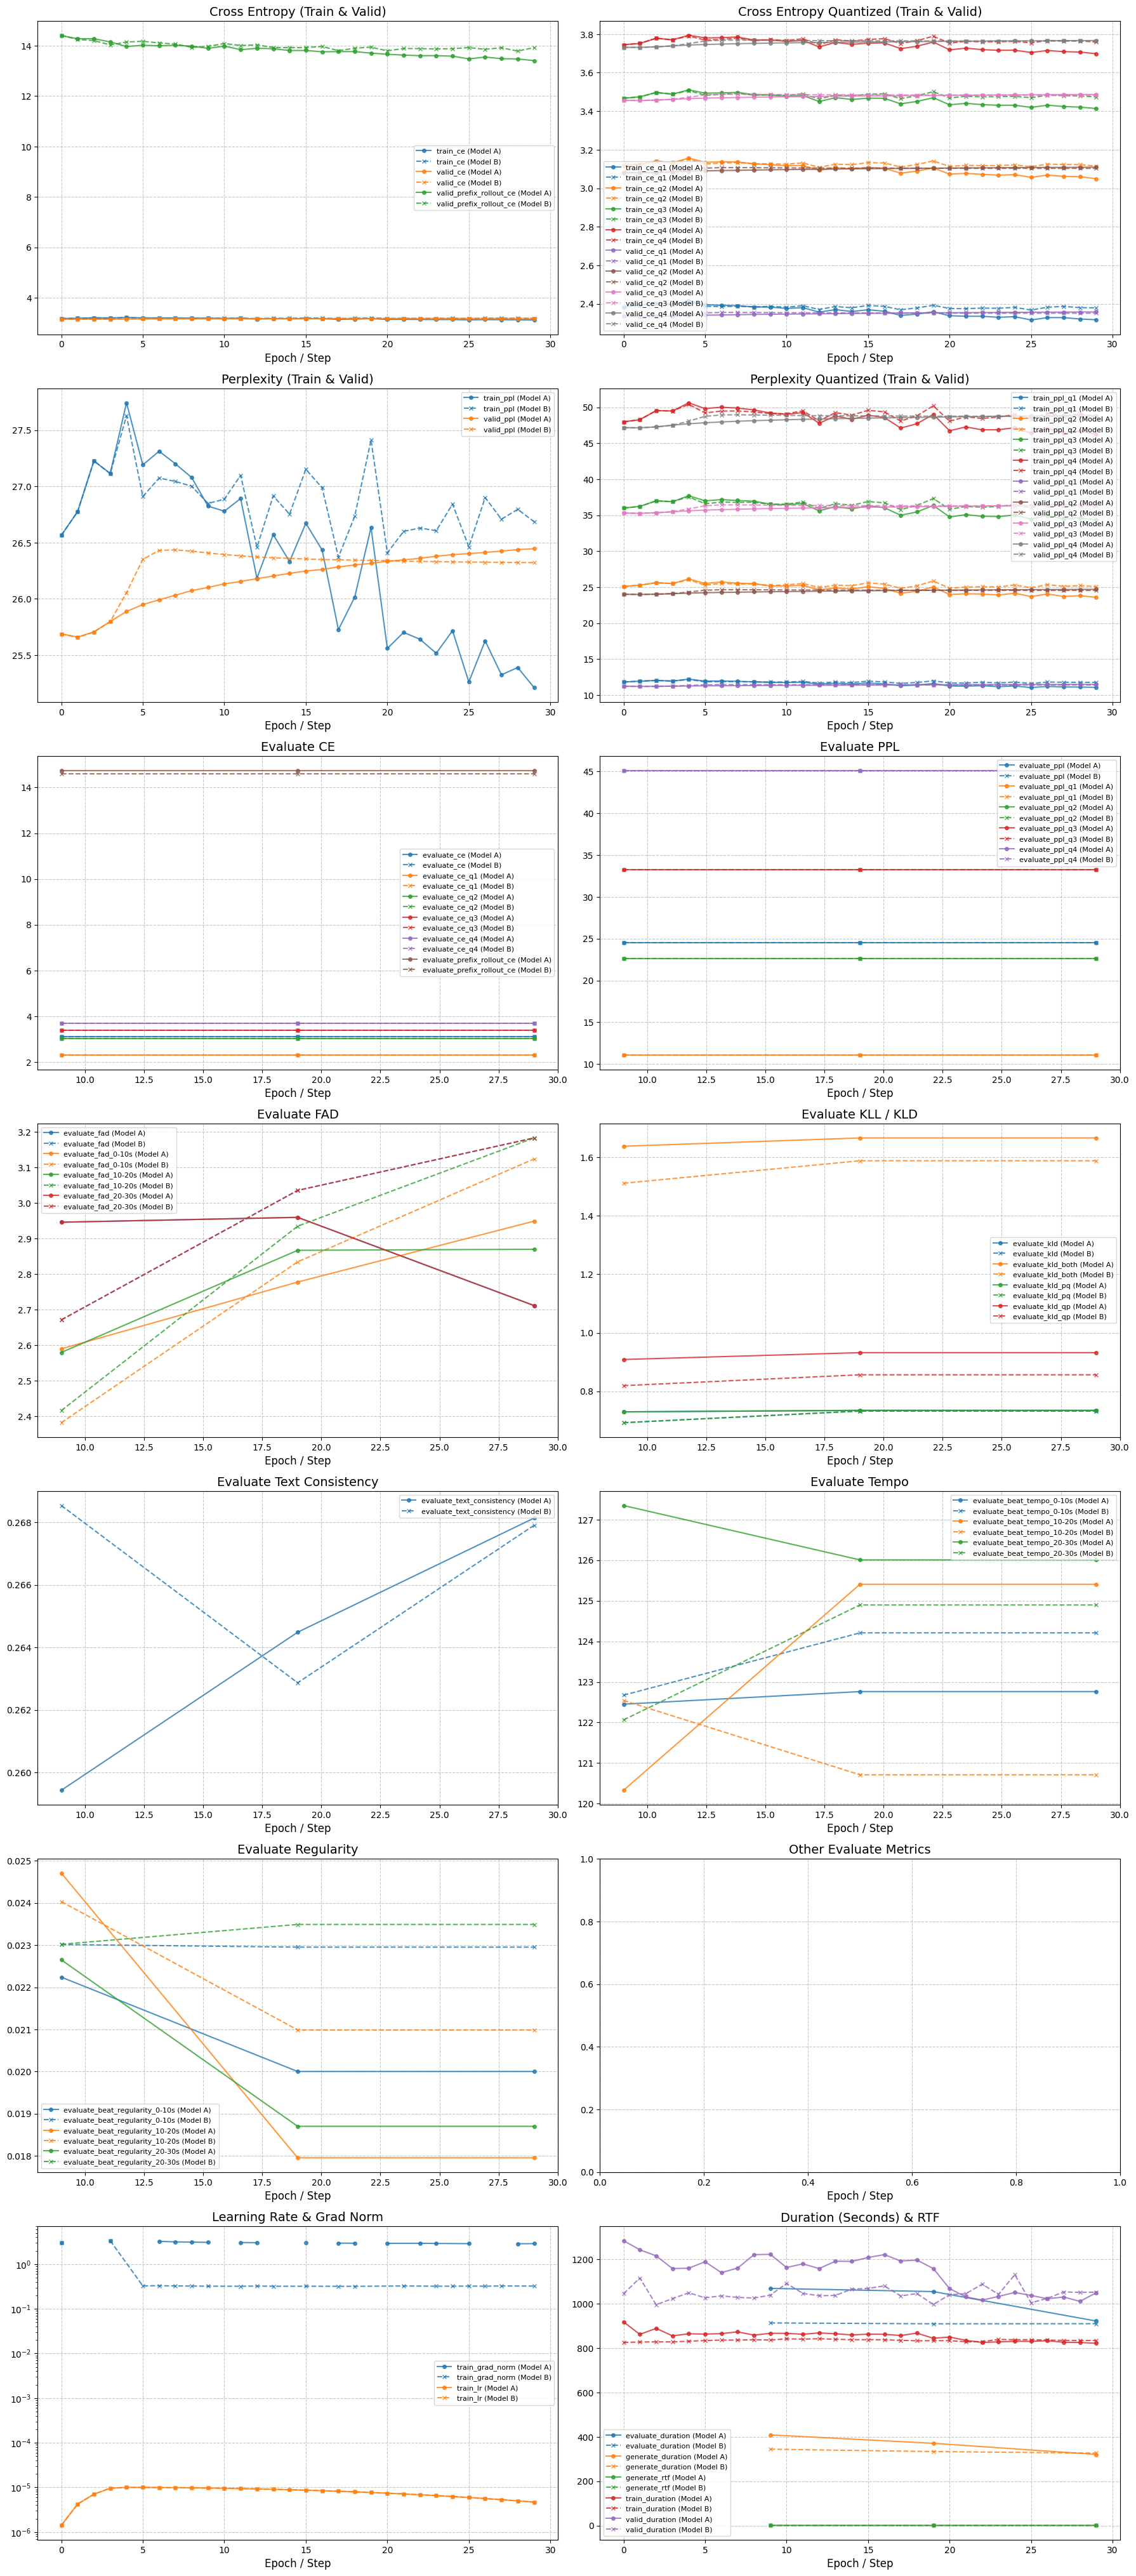

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_history(filepath):
    """Loads a JSON history file and flattens it into a pandas DataFrame."""
    with open(filepath, 'r') as f:
        data = json.load(f)
        
    records = []
    for i, step in enumerate(data):
        row = {'step': i}
        for phase, metrics in step.items():
            for k, v in metrics.items():
                row[f"{phase}_{k}"] = v
        records.append(row)
        
    return pd.DataFrame(records)

# --- Configuration ---
# Set your file paths and model labels here
MODEL_1_PATH = '/storage/ssd1/richtsai1103/Jamendo/dora_outputs/20260403_010611_teacher/xps/37b09569/history.json'
MODEL_2_PATH = '/storage/ssd1/richtsai1103/Jamendo/dora_outputs/20260403_224029/xps/68a2f0bf/history.json' # <-- UPDATE THIS

LABEL_1 = "Model A"
LABEL_2 = "Model B"

# Load data
df1 = load_history(MODEL_1_PATH)
df2 = load_history(MODEL_2_PATH)

# Get all unique columns across both models to ensure we don't miss any metrics
all_cols = list(set(df1.columns).union(set(df2.columns)))

# --- Grouping Logic (Applied to combined columns) ---
ce_cols = [c for c in all_cols if 'ce' in c and 'ce_q' not in c and 'evaluate' not in c]
ce_q_cols = [c for c in all_cols if 'ce_q' in c and 'evaluate' not in c]
ppl_cols = [c for c in all_cols if 'ppl' in c and 'ppl_q' not in c and 'evaluate' not in c]
ppl_q_cols = [c for c in all_cols if 'ppl_q' in c and 'evaluate' not in c]

eval_ce = [c for c in all_cols if 'evaluate' in c and 'ce' in c]
eval_ppl = [c for c in all_cols if 'evaluate' in c and 'ppl' in c]

eval_fad         = [c for c in all_cols if 'evaluate' in c and 'fad' in c.lower()]
eval_kll         = [c for c in all_cols if 'evaluate' in c and ('kll' in c.lower() or 'kld' in c.lower())]
eval_consistency = [c for c in all_cols if 'evaluate' in c and 'consistency' in c.lower()]
eval_tempo       = [c for c in all_cols if 'evaluate' in c and 'tempo' in c.lower()]
eval_regularity  = [c for c in all_cols if 'evaluate' in c and 'regularity' in c.lower()]
eval_other       = [c for c in all_cols if 'evaluate' in c
                    and 'ce' not in c and 'ppl' not in c and 'duration' not in c
                    and 'fad' not in c.lower() and 'kll' not in c.lower() and 'kld' not in c.lower()
                    and 'consistency' not in c.lower() and 'tempo' not in c.lower()
                    and 'regularity' not in c.lower()]

dur_cols = [c for c in all_cols if 'duration' in c or 'rtf' in c]

# --- Plotting ---
fig, axes = plt.subplots(8, 2, figsize=(18, 46))
axes = axes.flatten()

def plot_compare(ax, cols, title, logy=False):
    # Get standard matplotlib color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # Sort columns so colors align consistently
    cols = sorted(cols)
    
    for i, c in enumerate(cols):
        color = colors[i % len(colors)] # Assign a consistent color per metric
        
        # Plot Model 1 (Solid line, circle markers)
        if c in df1.columns:
            valid_data1 = df1[['step', c]].dropna()
            if not valid_data1.empty:
                ax.plot(valid_data1['step'], valid_data1[c], 
                        label=f"{c} ({LABEL_1})", 
                        color=color, linestyle='-', marker='o', markersize=4, alpha=0.8)
                
        # Plot Model 2 (Dashed line, 'x' markers)
        if c in df2.columns:
            valid_data2 = df2[['step', c]].dropna()
            if not valid_data2.empty:
                ax.plot(valid_data2['step'], valid_data2[c], 
                        label=f"{c} ({LABEL_2})", 
                        color=color, linestyle='--', marker='x', markersize=4, alpha=0.8)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Epoch / Step', fontsize=12)
    if logy:
        ax.set_yscale('log')
        
    # Only add legend if there's actually data plotted
    if ax.has_data():
        ax.legend(fontsize='8', loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)

# Core train/valid metrics
plot_compare(axes[0], ce_cols,    'Cross Entropy (Train & Valid)')
plot_compare(axes[1], ce_q_cols,  'Cross Entropy Quantized (Train & Valid)')
plot_compare(axes[2], ppl_cols,   'Perplexity (Train & Valid)')
plot_compare(axes[3], ppl_q_cols, 'Perplexity Quantized (Train & Valid)')

# Evaluate metrics
plot_compare(axes[4],  eval_ce,          'Evaluate CE')
plot_compare(axes[5],  eval_ppl,         'Evaluate PPL')
plot_compare(axes[6],  eval_fad,         'Evaluate FAD')
plot_compare(axes[7],  eval_kll,         'Evaluate KLL / KLD')
plot_compare(axes[8],  eval_consistency, 'Evaluate Text Consistency')
plot_compare(axes[9],  eval_tempo,       'Evaluate Tempo')
plot_compare(axes[10], eval_regularity,  'Evaluate Regularity')
plot_compare(axes[11], eval_other,       'Other Evaluate Metrics')

# Training diagnostics
plot_compare(axes[12], ['train_lr', 'train_grad_norm'], 'Learning Rate & Grad Norm', logy=True)
plot_compare(axes[13], dur_cols,                        'Duration (Seconds) & RTF')

# Hide empty subplots
axes[14].set_visible(False)
axes[15].set_visible(False)

plt.tight_layout()
plt.savefig('history_metrics_comparison.png', dpi=150, bbox_inches='tight')
print("Comparison plot saved to 'history_metrics_comparison.png'")

In [ ]:
import json
import matplotlib.pyplot as plt

def load_data(filepath):
    """Extracts the specific valid and rollout metrics from the history json."""
    with open(filepath, 'r') as f:
        data = json.load(f)
        
    epochs = range(len(data))
    valid_ce = [step['valid']['ce'] for step in data]
    rollout_ce = [step['valid']['prefix_rollout_ce'] for step in data]
    
    q_metrics = {
        'Q1 (Coarse)': [s['valid']['ce_q1'] for s in data],
        'Q2': [s['valid']['ce_q2'] for s in data],
        'Q3': [s['valid']['ce_q3'] for s in data],
        'Q4 (Fine)': [s['valid']['ce_q4'] for s in data]
    }
    
    return epochs, valid_ce, rollout_ce, q_metrics

# --- Configuration ---
MODEL_A_PATH = '/storage/ssd1/richtsai1103/MusicBench/dora_outputs/20260328_041339/xps/d0613dbf/history.json'
MODEL_B_PATH = '/storage/ssd1/richtsai1103/MusicBench/dora_outputs/path_to_model_2/history.json' # <-- UPDATE THIS

LABEL_A = "Model A"
LABEL_B = "Model B"

# Load data for both models
epochs_a, valid_ce_a, rollout_ce_a, q_metrics_a = load_data(MODEL_A_PATH)
epochs_b, valid_ce_b, rollout_ce_b, q_metrics_b = load_data(MODEL_B_PATH)


# ==========================================
# Plot 1: The Exposure Bias Gap Comparison
# ==========================================
plt.figure(figsize=(12, 6))

# Model A (Blues)
plt.plot(epochs_a, valid_ce_a, label=f'Teacher-Forced CE ({LABEL_A})', color='blue', lw=2, linestyle='-')
plt.plot(epochs_a, rollout_ce_a, label=f'Rollout CE ({LABEL_A})', color='blue', lw=2, linestyle=':')
plt.fill_between(epochs_a, valid_ce_a, rollout_ce_a, color='blue', alpha=0.1, label=f'Gap ({LABEL_A})')

# Model B (Reds)
plt.plot(epochs_b, valid_ce_b, label=f'Teacher-Forced CE ({LABEL_B})', color='red', lw=2, linestyle='-')
plt.plot(epochs_b, rollout_ce_b, label=f'Rollout CE ({LABEL_B})', color='red', lw=2, linestyle=':')
plt.fill_between(epochs_b, valid_ce_b, rollout_ce_b, color='red', alpha=0.1, label=f'Gap ({LABEL_B})')

plt.title('The Error Gap: Training vs. Real-World Rollout (Comparison)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross Entropy', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlapping data
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Plot 2: Per-Stream CE Comparison
# ==========================================
plt.figure(figsize=(12, 6))

# Define consistent colors for the 4 streams
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
stream_labels = list(q_metrics_a.keys())

for i, label in enumerate(stream_labels):
    # Model A: Solid lines
    plt.plot(epochs_a, q_metrics_a[label], label=f'{label} ({LABEL_A})', color=colors[i], linestyle='-', lw=2)
    # Model B: Dashed lines
    plt.plot(epochs_b, q_metrics_b[label], label=f'{label} ({LABEL_B})', color=colors[i], linestyle='--', lw=2, alpha=0.8)

plt.title('CE per Codebook Stream across Epochs (Comparison)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross Entropy', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2) 
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# ==========================================
# Console Output: Error Reduction 
# ==========================================
def print_reductions(model_label, q_metrics):
    print(f"\n--- Per-Stream Error Reduction (Epoch 0 to End): {model_label} ---")
    for label, values in q_metrics.items():
        if len(values) > 0:
            total_reduction = values[0] - values[-1]
            print(f"{label:<12}: {total_reduction:.4f} CE improvement")

print_reductions(LABEL_A, q_metrics_a)
print_reductions(LABEL_B, q_metrics_b)